In [137]:
%load_ext autoreload
%autoreload 2

[nltk_data] Downloading package punkt_tab to /Users/alice/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package brown to /Users/alice/nltk_data...
[nltk_data]   Package brown is already up-to-date!


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
from utils import *

In [140]:
from datasets import load_dataset
ds = load_dataset("rajpurkar/squad_v2")
dataset = ds["train"]

from transformers import pipeline

pipe = pipeline("question-answering", model="deepset/roberta-base-squad2")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [172]:
qa = dataset[7]
text = qa["context"]

content = ""
content += f"Context: {text}\n"
content += f"Question: {qa['question']}\n"
content += f"Answer: {qa['answers']['text'][0]}\n"
content += "\n"

for pick_func in [pick_baseline_random, pick_baseline_frequent, pick_entropy, pick_kl_divergence]:
    content += f"###############################\n"
    content += f"Pick Func: {pick_func.__name__}\n"
    for target_pct in [0.25, 0.5, 0.75]:
        content += f"Target Pct: {target_pct}\n"
        item, vocab = create_qa_item(qa, pick_func, target_pct, prior_vocab=[])
        a_pred = pipe(item)
        a_pred = a_pred["answer"]
        content += f"Vocab: {', '.join(vocab)}\n"
        content += f"Mask: {item['context']}\n"
        content += f"Answer: {a_pred}\n"
    content += "\n"

with open("assets/samples.txt", "w") as f:
    f.write(content)

/Users/alice/Documents/05-STANFORD/00-Courses/2 SOPHMORE/05-SOPH-AUT/CS109/Challenge/InfoLingo/.env/lib/python3.9/site-packages/transformers/pipelines/question_answering.py:391: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


In [171]:
print(content)

Context: Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child. Managed by her father, Mathew Knowles, the group became one of the world's best-selling girl groups of all time. Their hiatus saw the release of Beyoncé's debut album, Dangerously in Love (2003), which established her as a solo artist worldwide, earned five Grammy Awards and featured the Billboard Hot 100 number-one singles "Crazy in Love" and "Baby Boy".
Question: Who managed the Destiny's Child group?
Answer: Mathew Knowles

###############################
Pick Func: pick_baseline_random
Target Pct: 0.25
Vocab: september, she, dancing, dangerously, of, singing, is, group, giselle, as, hot, texas, love, crazy, earned, mathew, time, raised
Mask: 

In [173]:
corpus = get_corpus_word_probs()

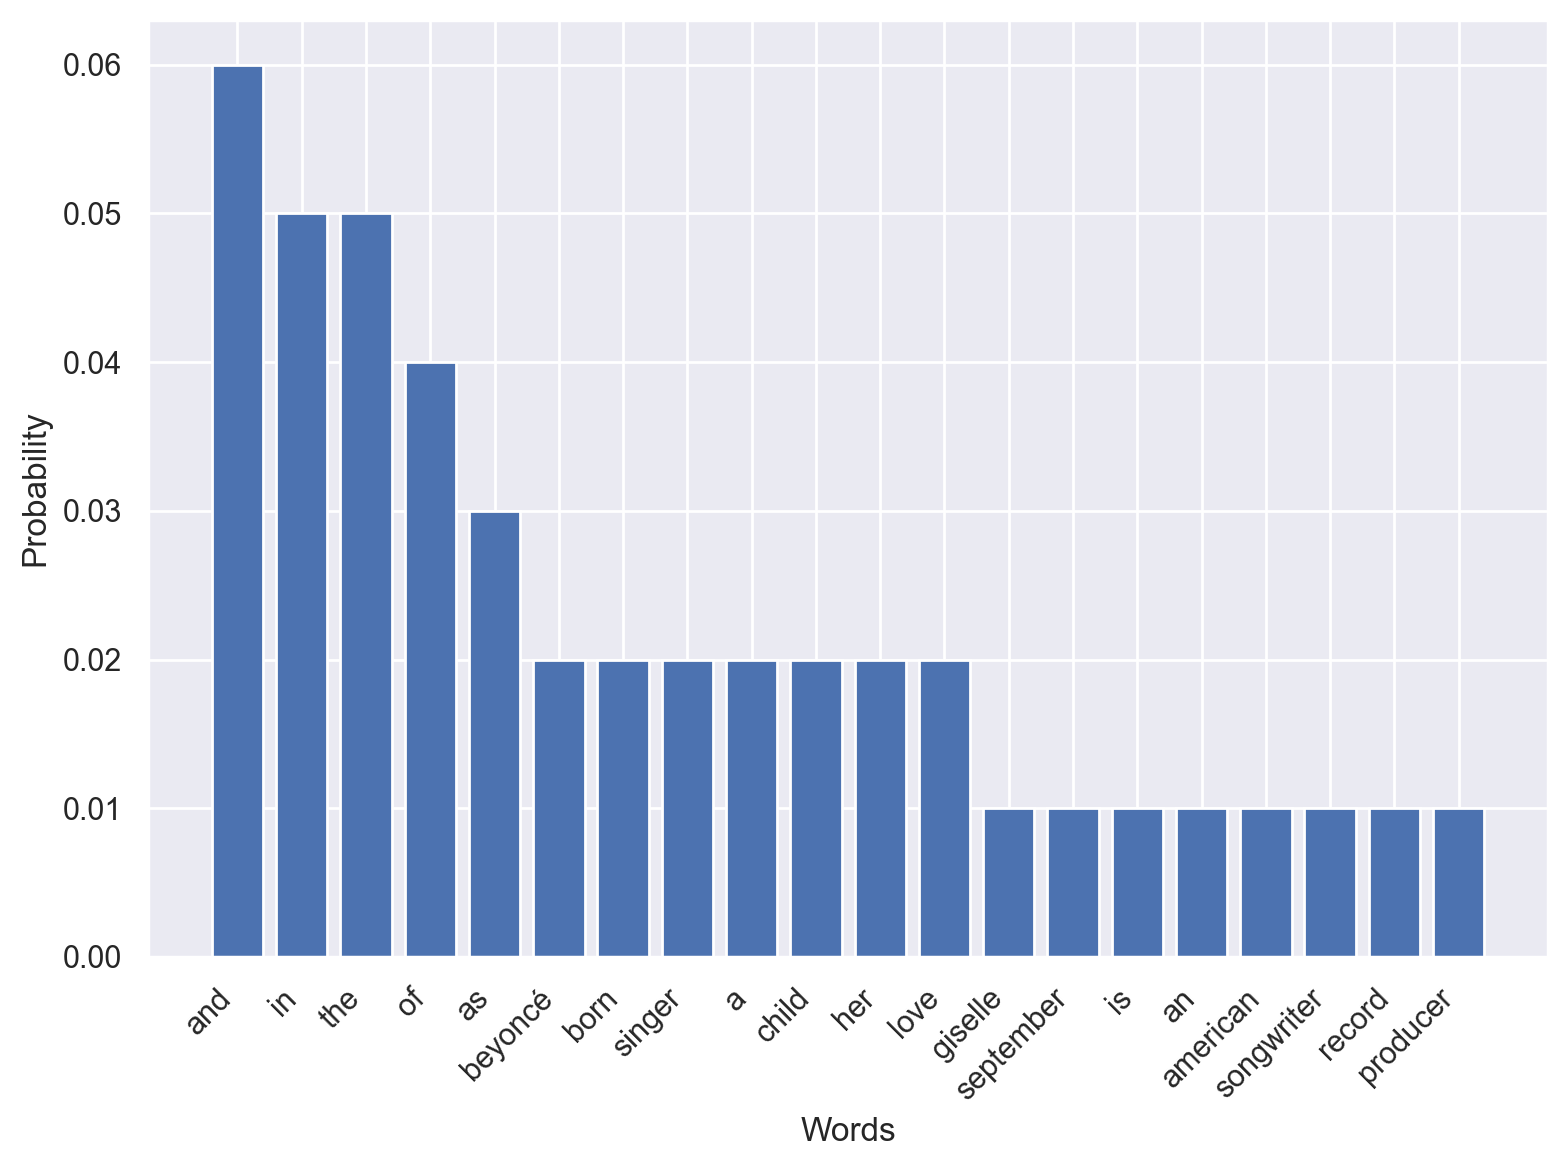

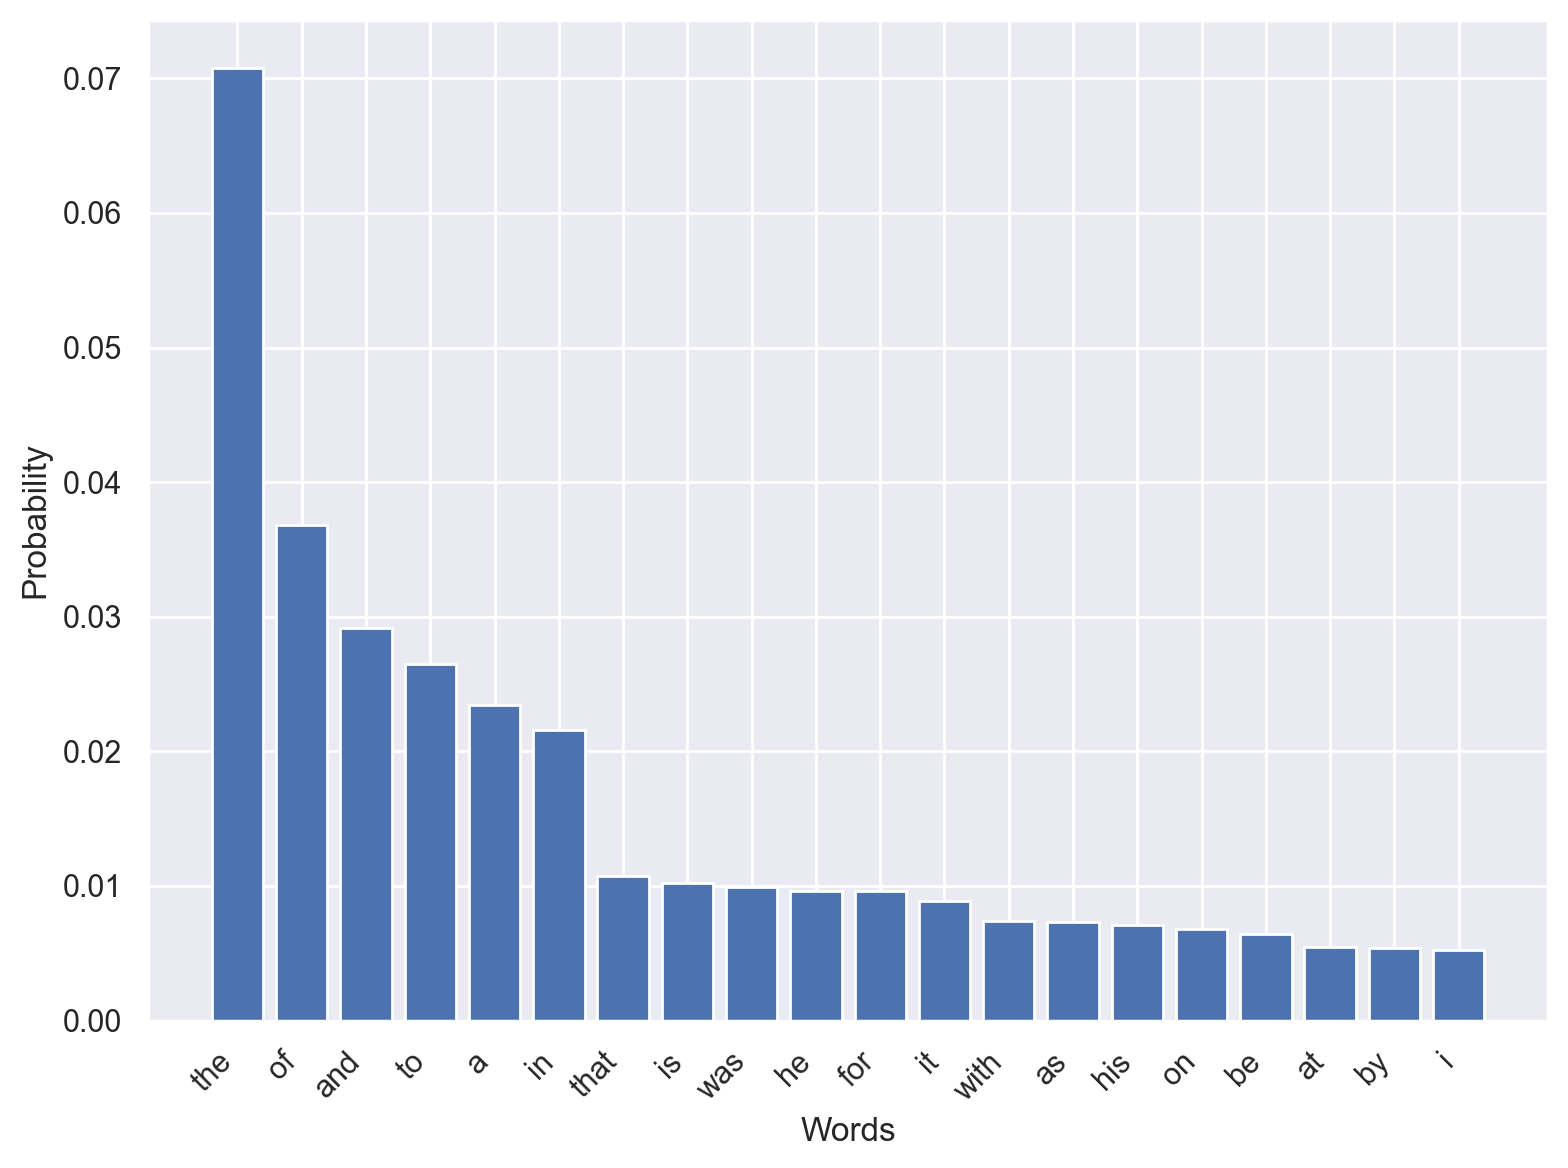

In [188]:
def get_barchart(word_probs, filename):
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme()

    # Sort the dictionary by probability and keep the top 20
    sorted_word_probabilities = dict(
        sorted(word_probs.items(), key=lambda item: item[1], reverse=True)[:20]
    )

    # Extract sorted words and probabilities
    words = list(sorted_word_probabilities.keys())
    probabilities = list(sorted_word_probabilities.values())

    # Create the bar chart
    plt.figure(figsize=(8, 6), dpi=200)
    plt.bar(words, probabilities)

    # Add labels and title
    plt.xlabel("Words", fontsize=12)
    plt.ylabel("Probability", fontsize=12)
    # plt.title("Top 20 Word Probabilities (Sorted)", fontsize=14)
    plt.xticks(rotation=45, ha="right")  # Rotate words for better readability

    # Show the chart
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()


words = tokenize_text(text)
word_counts, word_probs = get_word_stats(words)
get_barchart(word_probs, "assets/example-q-pmf.png")
get_barchart(corpus, "assets/example-C-pmf.png")